In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib
import os

In [2]:
df = pd.read_csv("ai_student_impact_dataset.csv")

print(df.shape)
print(df.head())

(50000, 16)
   Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0      100001     Humanities        Senior             2.418   
1      100002        Medical        Junior             3.821   
2      100003       Business      Freshman             3.398   
3      100004       Business        Senior             3.789   
4      100005           STEM     Sophomore             3.635   

   Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0               23.31       Copywriting/Drafting                 Beginner   
1                1.12                   Ideation                 Advanced   
2               21.26        Summarizing_Reading                 Beginner   
3                1.82       Copywriting/Drafting             Intermediate   
4                9.29  Debugging/Troubleshooting                 Advanced   

   Tool_Diversity  Paid_Subscription  Traditional_Study_Hours  \
0               1               True                     8.13   
1         

In [3]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64


/tmp/ipykernel_80724/2898259881.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Burnout_Risk_Level", palette="Set2")


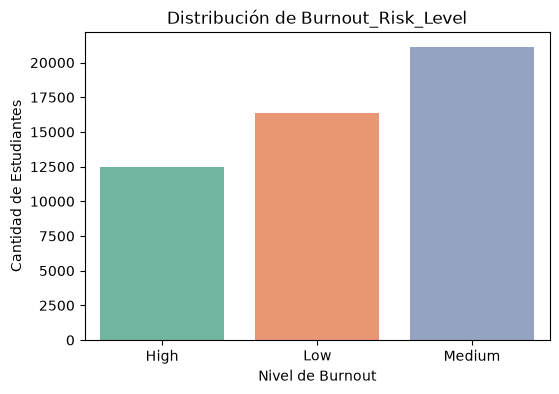

In [4]:
print(df["Burnout_Risk_Level"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Burnout_Risk_Level", palette="Set2")
plt.title("Distribución de Burnout_Risk_Level")
plt.xlabel("Nivel de Burnout")
plt.ylabel("Cantidad de Estudiantes")
plt.show()

In [5]:
columnas_numericas = ["Pre_Semester_GPA", "Weekly_GenAI_Hours", "Traditional_Study_Hours", "Post_Semester_GPA", "Skill_Retention_Score"]
df[columnas_numericas].describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Traditional_Study_Hours,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.146102,8.427752,11.209271,3.349299,75.798125
std,0.478854,8.269490,5.156426,0.495673,13.281626
min,1.183000,0.000000,1.000000,1.000000,10.780000
25%,2.834000,2.390000,7.560000,3.023750,66.820000
50%,3.210000,5.800000,11.180000,3.421000,76.000000
75%,3.521000,11.720000,14.710000,3.749000,85.190000
max,3.998000,40.000000,35.860000,4.000000,100.000000


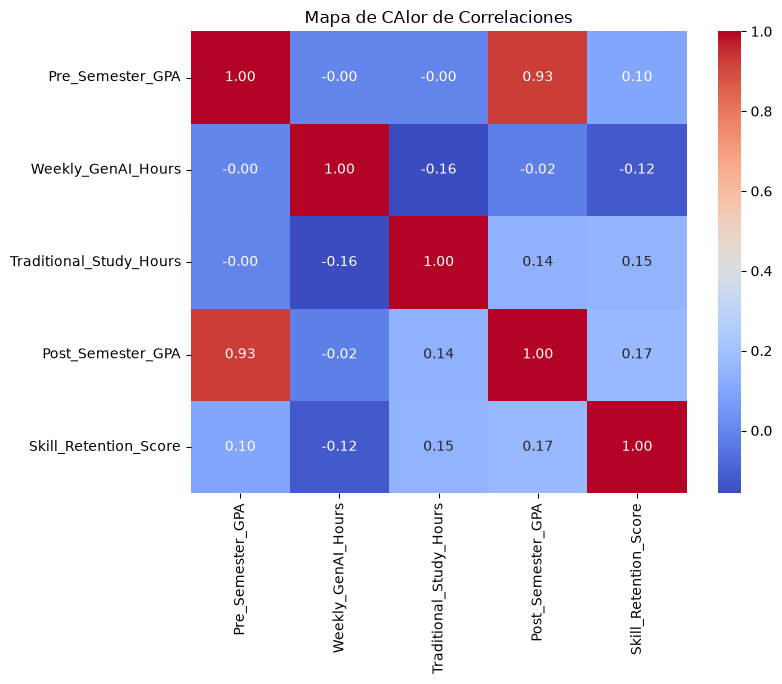

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[columnas_numericas].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de CAlor de Correlaciones")
plt.show()

In [7]:
X = df.drop(columns=['Student_ID', 'Burnout_Risk_Level'])
y = df['Burnout_Risk_Level']

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (50000, 14)
Dimensiones de y: (50000,)


In [8]:
# Definimos qué columnas pertenecen a cada tipo
num_cols = [
    'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours', 
    'Post_Semester_GPA', 'Skill_Retention_Score', 'Tool_Diversity', 
    'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Paid_Subscription'
]

# Categorías nominales (One-Hot Encoding)
nominal_cols = ['Major_Category', 'Primary_Use_Case', 'Institutional_Policy']

# Categorías ordinales (les asignamos un orden lógico explícito)
ordinal_cols = ['Year_of_Study', 'Prompt_Engineering_Skill']
categories_order = [
    ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate'],  # Orden de Year_of_Study
    ['Beginner', 'Intermediate', 'Advanced']                     # Orden de Prompt_Engineering_Skill
]

# Creamos el procesador de columnas
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_cols),
        ('ord', OrdinalEncoder(categories=categories_order), ordinal_cols)
    ])

# Aplicamos el preprocesamiento a X
X_procesado = preprocesador.fit_transform(X)

print("Datos preprocesados con éxito.")
print("Nueva dimensión de X:", X_procesado.shape)

Datos preprocesados con éxito.
Nueva dimensión de X: (50000, 24)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_procesado, y, test_size=0.2, random_state=42, stratify=y)

print("Datos para entrenamiento:", X_train.shape[0])
print("Datos para evaluación:", X_test.shape[0])

Datos para entrenamiento: 40000
Datos para evaluación: 10000


In [10]:
# Inicializar el modelo
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1)  

# Entrenar
print("Entrenando Random Forest...")
modelo_rf.fit(X_train, y_train)
print("¡Entrenamiento finalizado!")

Entrenando Random Forest...
¡Entrenamiento finalizado!


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

        High       0.67      0.45      0.53      2497
         Low       0.54      0.45      0.49      3274
      Medium       0.48      0.64      0.55      4229

    accuracy                           0.53     10000
   macro avg       0.56      0.51      0.53     10000
weighted avg       0.55      0.53      0.53     10000

--- Matriz de Confusión ---


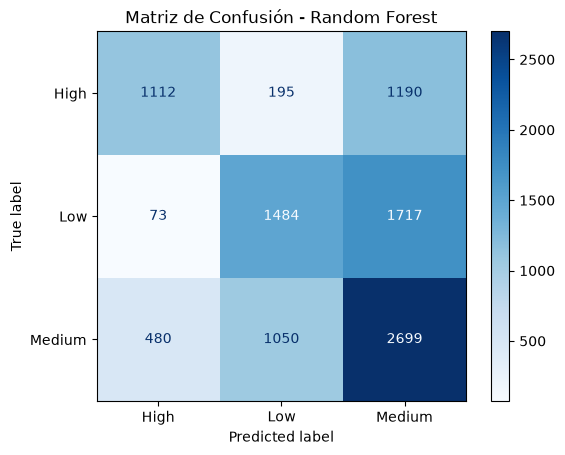

In [11]:
# Predicciones
y_pred = modelo_rf.predict(X_test)

# Reporte
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

# Matriz de confusión
print("--- Matriz de Confusión ---")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_rf.classes_)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Random Forest")
plt.show()

In [12]:
# Crear directorio de modelos si no existe
os.makedirs("models", exist_ok=True)

# Guardar
joblib.dump(preprocesador, "models/preprocessor.pkl")
joblib.dump(modelo_rf, "models/model.pkl")

print("¡Modelo y preprocesador guardados correctamente en la carpeta 'models/'!")

¡Modelo y preprocesador guardados correctamente en la carpeta 'models/'!
